In [1]:
# Step 1: Imports & Setup
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import time
import copy
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


Classes: ['E-waste', 'metal', 'organic', 'paper', 'plastic']


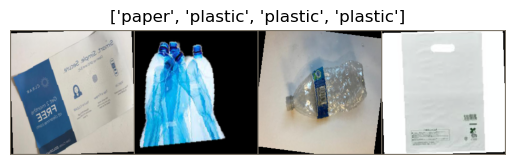

In [2]:
# Step 2: Load Dataset with Transforms

# Define image transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

# Dataset path
data_dir = r"C:\Users\gokul\OneDrive\Desktop\projects\waste_classifier\dataset"

# Load datasets
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transforms)

# Safer num_workers for Windows
num_workers = 0 if os.name == 'nt' else 4

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=num_workers)

# Class names
class_names = train_dataset.classes
print("Classes:", class_names)

# Optional: Visualize a few samples
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Show 4 training images
inputs, classes_ = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes_[:4]])

In [3]:
# Step 3: Load Pretrained ResNet18

# Load pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final fully connected layer for 5 output classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)  # 5 classes: E-waste, Metal, Organic, Paper, Plastic

# Move model to GPU if available
model = model.to(device)

print("✅ ResNet18 model ready on:", device)

# Optional: Print model structure
print(model)


✅ ResNet18 model ready on: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [4]:
# Step 4: Training & Validation Function

# Define loss function and optimizer (only training the final layer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training function
def train_model(model, dataloaders, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_acc_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train':
                train_acc_history.append(epoch_acc)
            else:
                val_acc_history.append(epoch_acc)

                # Save best model
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), "waste_model.pth")  # Save best model

    time_elapsed = time.time() - since
    print(f"\n⏱️ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"🎯 Best val Acc: {best_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history

# Create dataloaders dictionary
dataloaders = {
    'train': train_loader,
    'val': val_loader
}


In [5]:
# Step 5: Start Training

num_epochs = 10  # You can increase this if needed

# Train the model
model, train_hist, val_hist = train_model(
    model, 
    dataloaders, 
    criterion, 
    optimizer, 
    num_epochs=num_epochs
)



Epoch 1/10
--------------------
train Loss: 0.6341 Acc: 0.7935
val Loss: 0.3076 Acc: 0.9072

Epoch 2/10
--------------------
train Loss: 0.3387 Acc: 0.8928
val Loss: 0.2819 Acc: 0.8997

Epoch 3/10
--------------------
train Loss: 0.2814 Acc: 0.9070
val Loss: 0.2520 Acc: 0.9103

Epoch 4/10
--------------------
train Loss: 0.2625 Acc: 0.9055
val Loss: 0.2405 Acc: 0.9103

Epoch 5/10
--------------------
train Loss: 0.2418 Acc: 0.9160
val Loss: 0.2274 Acc: 0.9186

Epoch 6/10
--------------------
train Loss: 0.2265 Acc: 0.9219
val Loss: 0.2247 Acc: 0.9208

Epoch 7/10
--------------------
train Loss: 0.2270 Acc: 0.9204
val Loss: 0.2258 Acc: 0.9208

Epoch 8/10
--------------------
train Loss: 0.2077 Acc: 0.9279
val Loss: 0.2534 Acc: 0.9140

Epoch 9/10
--------------------
train Loss: 0.2030 Acc: 0.9304
val Loss: 0.2359 Acc: 0.9216

Epoch 10/10
--------------------
train Loss: 0.2051 Acc: 0.9285
val Loss: 0.2209 Acc: 0.9223

⏱️ Training complete in 15m 26s
🎯 Best val Acc: 0.9223


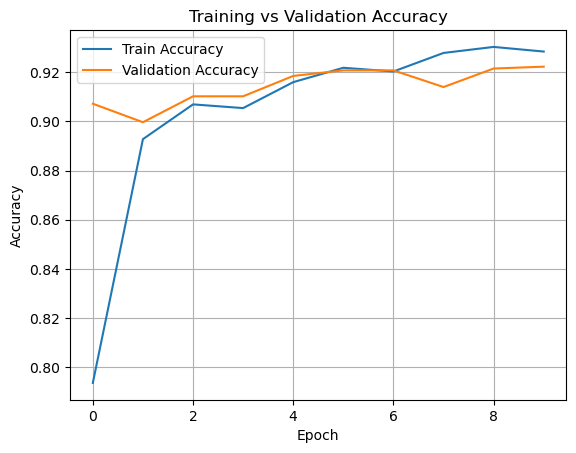

In [6]:
plt.plot([acc.cpu() for acc in train_hist], label='Train Accuracy')
plt.plot([acc.cpu() for acc in val_hist], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

     E-waste       0.93      0.99      0.96       189
       metal       0.84      0.88      0.86       204
     organic       0.97      0.97      0.97       200
       paper       0.95      0.91      0.93       336
     plastic       0.92      0.90      0.91       397

    accuracy                           0.92      1326
   macro avg       0.92      0.93      0.92      1326
weighted avg       0.92      0.92      0.92      1326



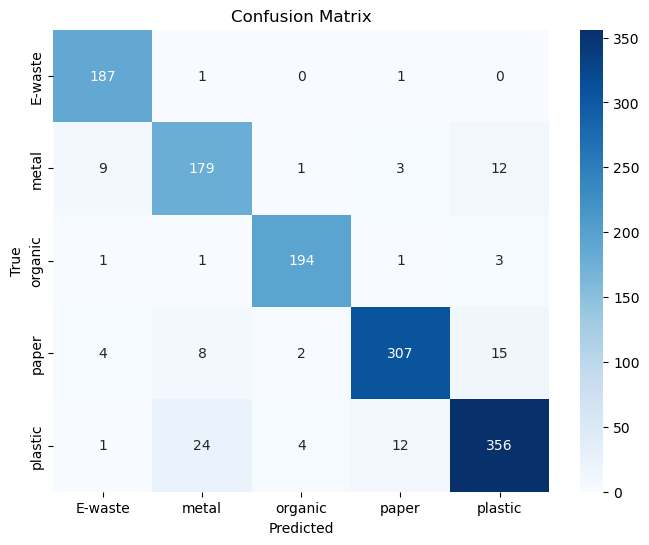

In [7]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [9]:
torch.save(model.state_dict(), "final_waste_model.pth")

In [10]:
def predict_image(img_path, model, transform, class_names):
    image = Image.open(img_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
    
    return class_names[predicted.item()]


In [11]:
img_path = r"C:\Users\gokul\OneDrive\Desktop\projects\waste_classifier\dataset\train\plastic\plastic_122.jpg"
print("Prediction:", predict_image(img_path, model, val_transforms, class_names))


Prediction: plastic
